# Parental Leave Data Analysis

## Objective
### To analyze parental leave policies and identify patterns and insights.

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("parental_leave.csv",  encoding="latin1")
print(df.head(20))

                            Company  \
0                           Epsilon   
1           The Walt Disney Company   
2                   Guild Education   
3                            WeWork   
4                      Randstad USA   
5                    Bain & Company   
6                          World 50   
7               ConAgra Foods, Inc.   
8                Anduril Industries   
9                  Northrop Grumman   
10        The University of Vermont   
11                           Belden   
12               Motorola Solutions   
13        MFS Investment Management   
14                            PIMCO   
15     Sandia National Laboratories   
16               Los Angeles County   
17  Federal Reserve Bank of Chicago   
18         Southern Health Partners   
19     Denver Health Medical Center   

                                        Industry  Paid Maternity Leave  \
0                                    Advertising                   6.0   
1                           Arts

### Basic info

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1601 entries, 0 to 1600
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Company                 1601 non-null   object 
 1   Industry                1598 non-null   object 
 2   Paid Maternity Leave    1601 non-null   float64
 3   Unpaid Maternity Leave  1494 non-null   float64
 4   Paid Paternity Leave    289 non-null    float64
 5   Unpaid Paternity Leave  64 non-null     float64
 6   Unnamed: 6              0 non-null      float64
 7   Unnamed: 7              0 non-null      float64
 8   Unnamed: 8              0 non-null      float64
 9   Unnamed: 9              0 non-null      float64
dtypes: float64(8), object(2)
memory usage: 125.2+ KB


,Paid Maternity Leave,Unpaid Maternity Leave,Paid Paternity Leave,Unpaid Paternity Leave,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
count,1601.000000,1494.000000,289.000000,64.000000,0.0,0.0,0.0,0.0
mean,10.909119,6.628849,7.332180,7.734375,NaN,NaN,NaN,NaN
std,8.024514,9.274953,6.817591,6.831863,NaN,NaN,NaN,NaN
min,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,6.000000,0.000000,2.000000,2.000000,NaN,NaN,NaN,NaN
50%,11.000000,4.000000,6.000000,6.000000,NaN,NaN,NaN,NaN
75%,12.000000,10.000000,12.000000,12.000000,NaN,NaN,NaN,NaN
max,52.000000,52.000000,51.000000,29.000000,NaN,NaN,NaN,NaN


##### A large number of paternity leave values are missing, suggesting that many companies may not provide or formally acknowledge fathers' needs in household and childcare responsibilities.

### Data Cleaning

In [4]:
df = df.drop(columns=df.filter(like = "Unnamed").columns)
df.isnull().sum()

Company                      0
Industry                     3
Paid Maternity Leave         0
Unpaid Maternity Leave     107
Paid Paternity Leave      1312
Unpaid Paternity Leave    1537
dtype: int64

##### There are missing values in columns because many companies did not provide this data.This represents real-world data gaps rather than errors.

In [5]:
df = df.dropna(subset=['Industry'])

### Exploratory Data Analysis (EDA)

#### Distribution of Paid Maternity Leave

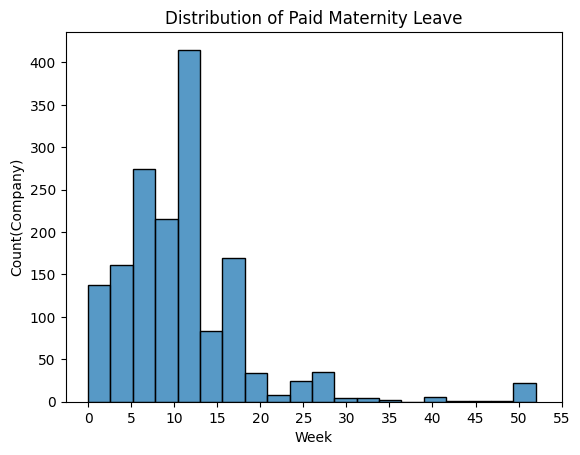

In [6]:
sns.histplot(df["Paid Maternity Leave"], bins = 20)
plt.title("Distribution of Paid Maternity Leave")
plt.xlabel("Week")
plt.ylabel("Count(Company)")
plt.xticks(range(0, 60, 5))
plt.show()

##### The majority of companies provide paid maternity leave in the range of 5–15 weeks. The distribution is positively skewed, with a small number of companies offering extended leave up to 50 weeks, which can be considered outliers.

#### Distribution of Paid Paternity Leave

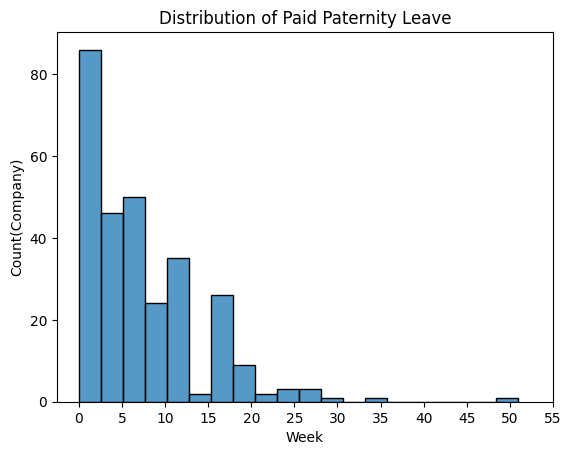

In [7]:
sns.histplot(df["Paid Paternity Leave"], bins = 20)
plt.title("Distribution of Paid Paternity Leave")
plt.xlabel("Week")
plt.ylabel("Count(Company)")
plt.xticks(range(0, 60, 5))
plt.show()

##### Some companies provide paid Paternity leave in the range of 5–10 weeks.

#### Paid vs Unpaid Maternity Leave

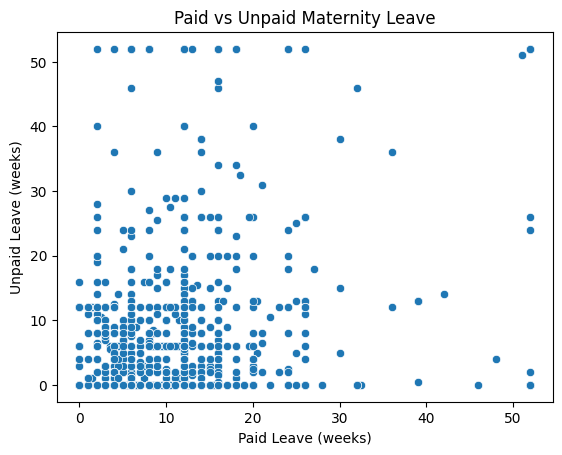

In [8]:
sns.scatterplot(x = 'Paid Maternity Leave', y = 'Unpaid Maternity Leave', data = df)
plt.title("Paid vs Unpaid Maternity Leave")
plt.xlabel("Paid Leave (weeks)")
plt.ylabel("Unpaid Leave (weeks)")
plt.show()

##### There is no clear correlation between paid and unpaid maternity leave. Most companies offer limited unpaid leave, while paid leave varies significantly.

#### Paid vs Unpaid Paternity Leave

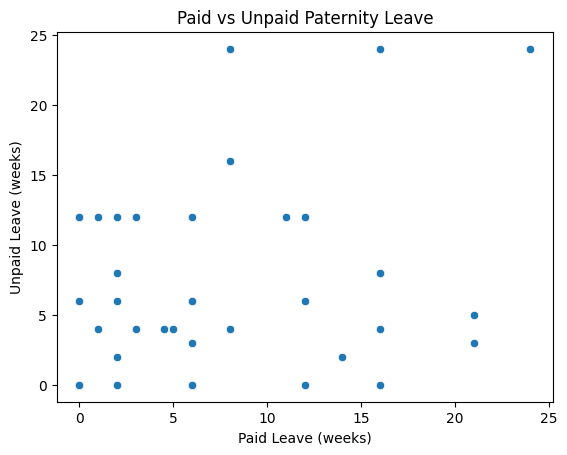

In [9]:
sns.scatterplot(x = 'Paid Paternity Leave', y = 'Unpaid Paternity Leave', data = df)
plt.title("Paid vs Unpaid Paternity Leave")
plt.xlabel("Paid Leave (weeks)")
plt.ylabel("Unpaid Leave (weeks)")
plt.show()

##### There is no clear correlation between paid and unpaid Paternity leave. 

#### Unpaid Maternity Leave vs Unpaid Paternity Leave

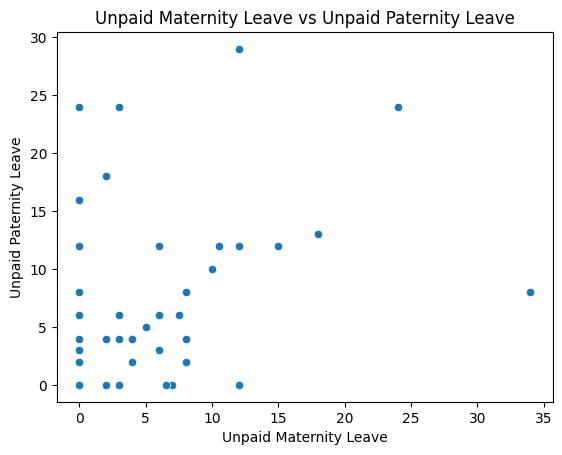

In [10]:
sns.scatterplot(x = 'Unpaid Maternity Leave', y = 'Unpaid Paternity Leave', data = df)
plt.title("Unpaid Maternity Leave vs Unpaid Paternity Leave")
plt.show()

#### Paid Maternity Leave vs Paid Paternity Leave

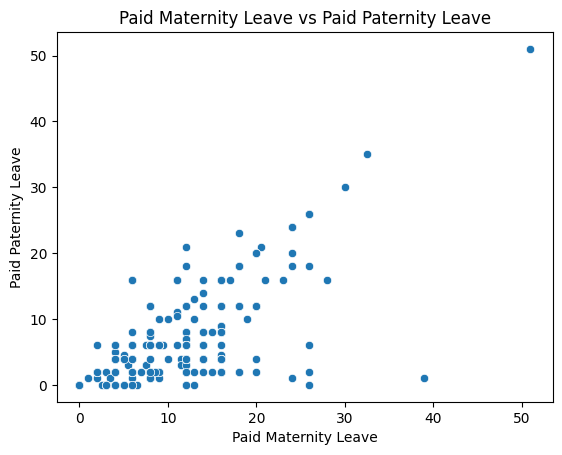

In [11]:
sns.scatterplot(x = 'Paid Maternity Leave', y = 'Paid Paternity Leave', data = df)
plt.title("Paid Maternity Leave vs Paid Paternity Leave")
plt.show()

##### The scatter plot shows a slight positive relationship between paid maternity and paid paternity leave. Companies that offer higher maternity leave tend to offer somewhat higher paternity leave as well. However, the relationship is not strong, and there is significant variation across companies, indicating that paternity leave policies are less standardized.

#### Correlation

In [12]:
df[['Paid Maternity Leave', 'Unpaid Maternity Leave']].corr()

,Paid Maternity Leave,Unpaid Maternity Leave
Paid Maternity Leave,1.000000,0.075969
Unpaid Maternity Leave,0.075969,1.000000


In [13]:
df[['Paid Paternity Leave', 'Unpaid Paternity Leave']].corr()

,Paid Paternity Leave,Unpaid Paternity Leave
Paid Paternity Leave,1.000000,0.096189
Unpaid Paternity Leave,0.096189,1.000000


##### Both maternity and paternity leave policies show very weak correlation between paid and unpaid components, indicating that companies design paid and unpaid leave independently.

### Key Insights
##### Most companies offer between 5–15 weeks of paid maternity leave.
##### Paid and unpaid maternity leave show little to no correlation.
##### Paternity leave data is largely missing, suggesting limited support or reporting.
##### Leave policies vary significantly across industries.
##### A few companies provide significantly higher leave benefits (outliers).

### Conclusion

##### This analysis shows that parental leave policies vary widely across companies. 
##### Maternity leave is more commonly reported, while paternity leave is often missing, 
##### indicating potential gaps in workplace support for fathers. Overall, paid and unpaid 
##### leave policies appear to be designed independently.